In [1]:
"""
Created on 17-09-2026

@author: B.A. Sturre

EDA on the smart meters data
"""

import glob 
import matplotlib.pyplot as plt 
import numpy as np 
import os 
import pandas as pd 
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

os.makedirs('./plots', exist_ok=True)

In [2]:
block_files = sorted(glob.glob("./data/halfhourly_dataset/halfhourly_dataset/block_*.csv"))
if not block_files:
    block_files = sorted(glob.glob("./data/halfhourly_dataset/block_*.csv"))

print(f"Total block files found: {len(block_files)}")

Total block files found: 112


In [3]:
# single meter structure
sample_block = pd.read_csv(block_files[0], nrows=5)
print("\n--- Smart Meter Block Sample (Shape & Columns) ---")
print(f"Shape: {sample_block.shape}")
print(f"Columns: {sample_block.columns.tolist()}")
display(sample_block.head())


--- Smart Meter Block Sample (Shape & Columns) ---
Shape: (5, 3)
Columns: ['LCLid', 'tstp', 'energy(kWh/hh)']


,LCLid,tstp,energy(kWh/hh)
0,MAC000002,2012-10-12 00:30:00.0000000,0
1,MAC000002,2012-10-12 01:00:00.0000000,0
2,MAC000002,2012-10-12 01:30:00.0000000,0
3,MAC000002,2012-10-12 02:00:00.0000000,0
4,MAC000002,2012-10-12 02:30:00.0000000,0


In [4]:
# weather structure
weather_path = "./data/weather_hourly_darksky.csv"
if os.path.exists(weather_path):
    sample_weather = pd.read_csv(weather_path, nrows=5)
    print("\n--- Weather File Sample (Shape & Columns) ---")
    print(f"Shape: {sample_weather.shape}")
    print(f"Columns: {sample_weather.columns.tolist()}")
    display(sample_weather.head())

    # check timestamps
    t_block = pd.to_datetime(sample_block.iloc[:, 1])
    t_weather = pd.to_datetime(sample_weather["time"])
    print(f"\nBlock timestamp dtype:   {t_block.dtype}")
    print(f"Weather timestamp dtype: {t_weather.dtype}")


--- Weather File Sample (Shape & Columns) ---
Shape: (5, 12)
Columns: ['visibility', 'windBearing', 'temperature', 'time', 'dewPoint', 'pressure', 'apparentTemperature', 'windSpeed', 'precipType', 'icon', 'humidity', 'summary']


,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy



Block timestamp dtype:   datetime64[ns]
Weather timestamp dtype: datetime64[us]


In [5]:
def load(data_dir: str, num_blocks: int = 5) -> pd.DataFrame:
    """
    reading smart meter blocks, standardizing columns, and aggregating grid load
    """
    # filepath 
    block_pattern = os.path.join(
        data_dir, "halfhourly_dataset", "halfhourly_dataset", "block_*.csv"
    )
    block_files = sorted(glob.glob(block_pattern))[:num_blocks]

    if not block_files:
        block_files = sorted(
            glob.glob(os.path.join(data_dir, "halfhourly_dataset", "block_*.csv"))
        )[:num_blocks]

    # reading all the files
    dfs = []
    for file in block_files:
        df = pd.read_csv(file)
        df.columns = [c.strip().lower() for c in df.columns]
        energy_col = [c for c in df.columns if "kwh" in c or "energy" in c][0]
        time_col = [c for c in df.columns if "tstp" in c or "time" in c][0]
        df["energy"] = pd.to_numeric(df[energy_col], errors="coerce")
        df["timestamp"] = pd.to_datetime(df[time_col], errors="coerce").astype("datetime64[s]")
        dfs.append(df[["timestamp", "energy"]].dropna(subset=["timestamp"]))

    full_df = pd.concat(dfs, ignore_index=True)

    grid_load = (
        full_df.groupby("timestamp")["energy"]
        .agg(total_load_kwh="sum", mean_load_kwh="mean", meter_count="count")
        .reset_index()
    )
    return grid_load


def merge_weather_data(grid_df: pd.DataFrame, weather_path: str) -> pd.DataFrame:
    """
    merging weather observations
    """
    # reading data
    weather = pd.read_csv(weather_path)
    weather["time"] = pd.to_datetime(weather["time"]).astype("datetime64[s]")

    # sorting
    grid_df = grid_df.sort_values("timestamp")
    weather = weather.sort_values("time")

    # merging
    merged = pd.merge_asof(
        grid_df,
        weather[["time", "temperature", "humidity", "windSpeed"]],
        left_on="timestamp",
        right_on="time",
        direction="nearest",
    )
    return merged


In [6]:
DATA_DIR = "./data"

grid_df = load(DATA_DIR, num_blocks=5)

# loading weather file
weather_file = os.path.join(DATA_DIR, "weather_hourly_darksky.csv")
if os.path.exists(weather_file):
    grid_df = merge_weather_data(grid_df, weather_file)

grid_df["hour"] = grid_df["timestamp"].dt.hour
grid_df["dayofweek"] = grid_df["timestamp"].dt.day_name()

# peak-to-average ratio
par = grid_df["total_load_kwh"].max() / grid_df["total_load_kwh"].mean()

print(f"timespan: {grid_df['timestamp'].min()} - {grid_df['timestamp'].max()}")
print(f"total half-hourly data points: {len(grid_df)}")
print(f"grid peak-to-average ratio (PAR): {par:.2f}")

timespan: 2011-11-23 12:30:00 - 2014-02-28 00:00:00
total half-hourly data points: 39904
grid peak-to-average ratio (PAR): 3.42


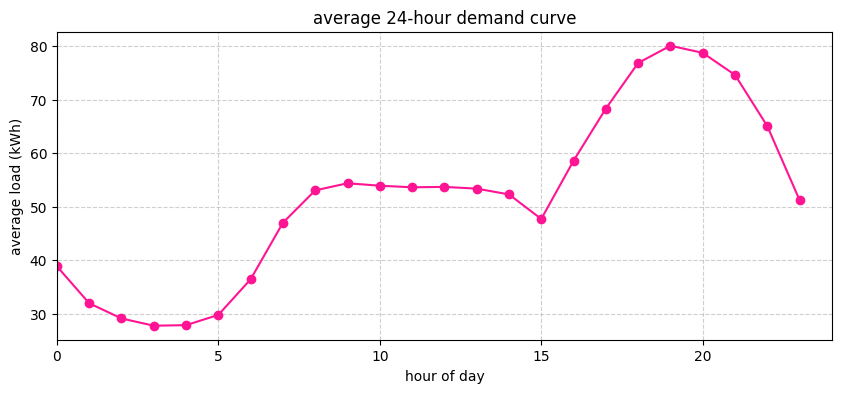

In [7]:
# 24 hour demand curve
plt.figure(figsize=(10, 4))
hourly_profile = grid_df.groupby("hour")["total_load_kwh"].mean()
plt.plot(hourly_profile.index, hourly_profile.values, marker="o", color="deeppink")
plt.title("average 24-hour demand curve")
plt.xlabel("hour of day")
plt.ylabel("average load (kWh)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlim(0, 24)
plt.savefig('./plots/average_24h.png')
plt.show()

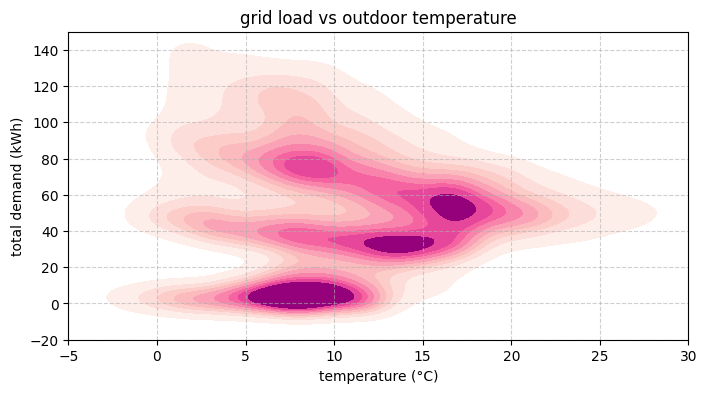

In [8]:
# weather vs demand
plt.figure(figsize=(8, 4))
sns.kdeplot(x=grid_df["temperature"], y=grid_df["total_load_kwh"], 
            fill=True,
            cmap="RdPu",
            thresh=0.05,
            levels=10)
plt.title("grid load vs outdoor temperature")
plt.xlabel("temperature (°C)")
plt.ylabel("total demand (kWh)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.ylim(-20, 150)
plt.xlim(-5, 30)
plt.savefig('./plots/grid_load-temperature.png')
plt.show()

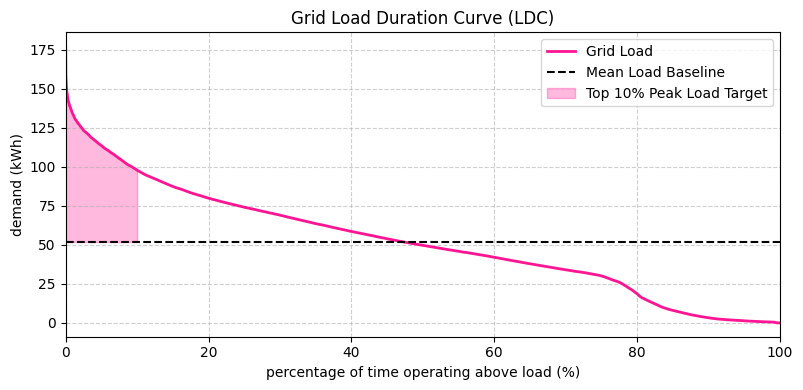

In [9]:
plt.figure(figsize=(8, 4))
sorted_load = grid_df['total_load_kwh'].sort_values(ascending=False).values
duration_pct = np.linspace(0, 100, len(sorted_load))
plt.plot(duration_pct, sorted_load, color='deeppink', linewidth=2, label='Grid Load')
plt.axhline(y=grid_df['total_load_kwh'].mean(), color='black', linestyle='--', label='Mean Load Baseline')
peak_cutoff = np.percentile(sorted_load, 90)
plt.fill_between(duration_pct, sorted_load, mean_load_val := grid_df['total_load_kwh'].mean(), 
                 where=(sorted_load >= peak_cutoff), color='deeppink', alpha=0.3, label='Top 10% Peak Load Target')

plt.title("Grid Load Duration Curve (LDC)")
plt.xlabel("percentage of time operating above load (%)")
plt.ylabel("demand (kWh)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.xlim(0, 100)
plt.savefig('./plots/load_duration_curve.png')
plt.show()

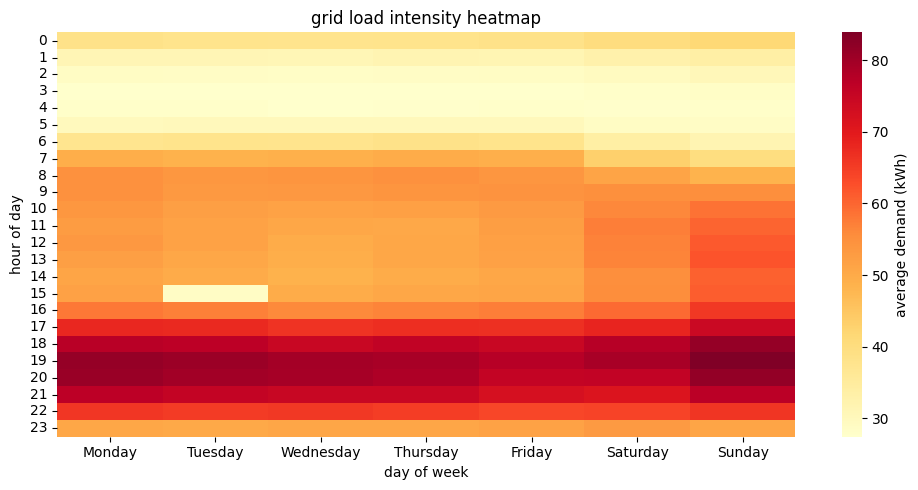

In [10]:
# Ensure standard day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_load = grid_df.pivot_table(
    index='hour', 
    columns='dayofweek', 
    values='total_load_kwh', 
    aggfunc='mean'
).reindex(columns=day_order)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_load, cmap="YlOrRd", cbar_kws={'label': 'average demand (kWh)'})

plt.title("grid load intensity heatmap")
plt.xlabel("day of week")
plt.ylabel("hour of day")
plt.tight_layout()
plt.savefig('./plots/weekly_load_heatmap.png')
plt.show()

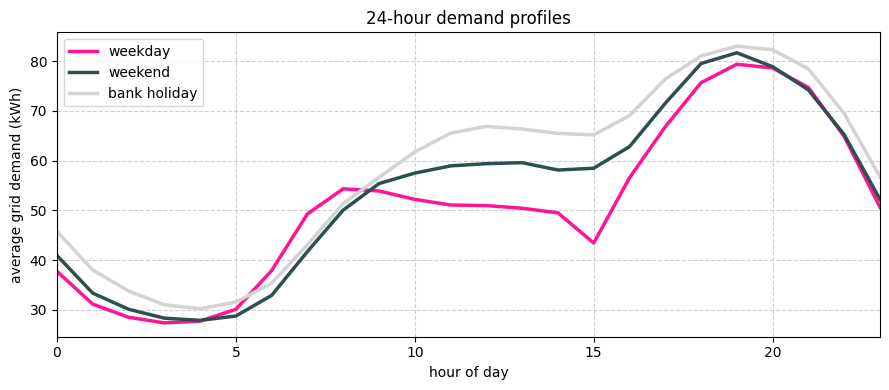

In [11]:
# loading holidays data
holidays_path = "./data/uk_bank_holidays.csv"
holidays_df = pd.read_csv(holidays_path)
holiday_col = holidays_df.columns[0]
holiday_dates = pd.to_datetime(holidays_df[holiday_col], errors='coerce').dt.date.dropna()

# dating
grid_df['date'] = grid_df['timestamp'].dt.date
grid_df['is_bank_holiday'] = grid_df['date'].isin(holiday_dates)
grid_df['is_weekend'] = grid_df['timestamp'].dt.dayofweek.isin([5, 6])

# catogorizing the days
def categorize_day(row):
    if row['is_bank_holiday']:
        return 'bank holiday'
    elif row['is_weekend']:
        return 'weekend'
    return 'weekday'

grid_df['day_type'] = grid_df.apply(categorize_day, axis=1)

# plotting
plt.figure(figsize=(9, 4))
sns.lineplot(
    data=grid_df, 
    x='hour', 
    y='total_load_kwh', 
    hue='day_type', 
    palette={'weekday': 'deeppink', 'weekend': 'darkslategray', 'bank holiday': 'lightgray'},
    errorbar=None,
    linewidth=2.5
)
plt.legend()
plt.title("24-hour demand profiles")
plt.xlabel("hour of day")
plt.ylabel("average grid demand (kWh)")
plt.xlim(0, 23)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig('./plots/day_type_demand_profiles.png')
plt.show()

In [12]:
holidays_path = "./data/uk_bank_holidays.csv"
# loading data
holidays_df = pd.read_csv(holidays_path)
date_col = holidays_df.columns[0]
holiday_dates = set(pd.to_datetime(holidays_df[date_col], format='mixed', errors='coerce').dt.date.dropna())

# separating
grid_df['date'] = grid_df['timestamp'].dt.date
grid_df['is_bank_holiday'] = grid_df['date'].isin(holiday_dates)
grid_df['is_weekend'] = grid_df['timestamp'].dt.dayofweek.isin([5, 6])

def categorize_day(row):
    if row['is_bank_holiday']:
        return 'Bank Holiday'
    elif row['is_weekend']:
        return 'Weekend'
    return 'Weekday'

grid_df['day_type'] = grid_df.apply(categorize_day, axis=1)

print(grid_df['day_type'].value_counts())

day_type
Weekday         27760
Weekend         11280
Bank Holiday      864
Name: count, dtype: int64


In [13]:
# non-emtpy group extracting
groups_dict = {
    day_type: group['total_load_kwh'].dropna().values 
    for day_type, group in grid_df.groupby('day_type') 
    if len(group['total_load_kwh'].dropna()) >= 2
}

print(f"Active testing categories: {list(groups_dict.keys())}")

# run tests
if len(groups_dict) >= 2:
    group_data = list(groups_dict.values())
    
    f_stat, p_val_anova = stats.f_oneway(*group_data)
    h_stat, p_val_kw = stats.kruskal(*group_data)

    print(f"One-Way ANOVA:      F = {f_stat:.4f}, p-value = {p_val_anova:.4e}")
    print(f"Kruskal-Wallis H:   H = {h_stat:.4f}, p-value = {p_val_kw:.4e}")

    alpha = 0.05
    if p_val_kw < alpha:
        print(f"\nResult: Reject Null Hypothesis (p < {alpha}). Profiles are significantly different.")
    else:
        print(f"\nResult: Fail to reject Null Hypothesis (p >= {alpha}). Profiles are not significantly different.")

    active_df = grid_df[grid_df['day_type'].isin(groups_dict.keys())]
    tukey_result = pairwise_tukeyhsd(
        endog=active_df['total_load_kwh'], 
        groups=active_df['day_type'], 
        alpha=alpha
    )
    print(tukey_result)

Active testing categories: ['Bank Holiday', 'Weekday', 'Weekend']
One-Way ANOVA:      F = 39.4628, p-value = 7.5587e-18
Kruskal-Wallis H:   H = 58.6438, p-value = 1.8436e-13

Result: Reject Null Hypothesis (p < 0.05). Profiles are significantly different.
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1     group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------------
Bank Holiday Weekday  -6.7689    0.0 -9.5049  -4.033   True
Bank Holiday Weekend  -4.0363 0.0021 -6.8319 -1.2406   True
     Weekday Weekend   2.7327    0.0  1.8484   3.617   True
-----------------------------------------------------------


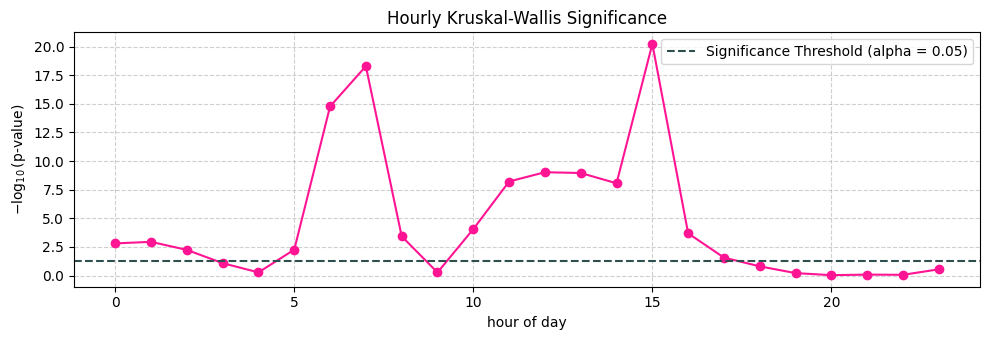

In [14]:
hourly_p_values = []

for h in range(24):
    sub_df = grid_df[grid_df['hour'] == h]
    
    # extract non-empty category arrays for the current hour
    hourly_groups = [
        group['total_load_kwh'].dropna().values 
        for _, group in sub_df.groupby('day_type') 
        if len(group['total_load_kwh'].dropna()) >= 2
    ]
    
    # perform Kruskal-Wallis only if 2 or more groups exist for this hour
    if len(hourly_groups) >= 2:
        _, p_val = stats.kruskal(*hourly_groups)
    else:
        p_val = np.nan
        
    hourly_p_values.append({'hour': h, 'p_value': p_val})

hourly_stats_df = pd.DataFrame(hourly_p_values).dropna()

# plotting 
plt.figure(figsize=(10, 3.5))
plt.plot(hourly_stats_df['hour'], -np.log10(hourly_stats_df['p_value'] + 1e-300), marker='o', color='deeppink')
plt.axhline(y=-np.log10(0.05), color='darkslategray', linestyle='--', label='Significance Threshold (alpha = 0.05)')
plt.title("Hourly Kruskal-Wallis Significance")
plt.xlabel("hour of day")
plt.ylabel(r"$-\log_{10}$(p-value)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig('./plots/hourly_significance_test.png')
plt.show()

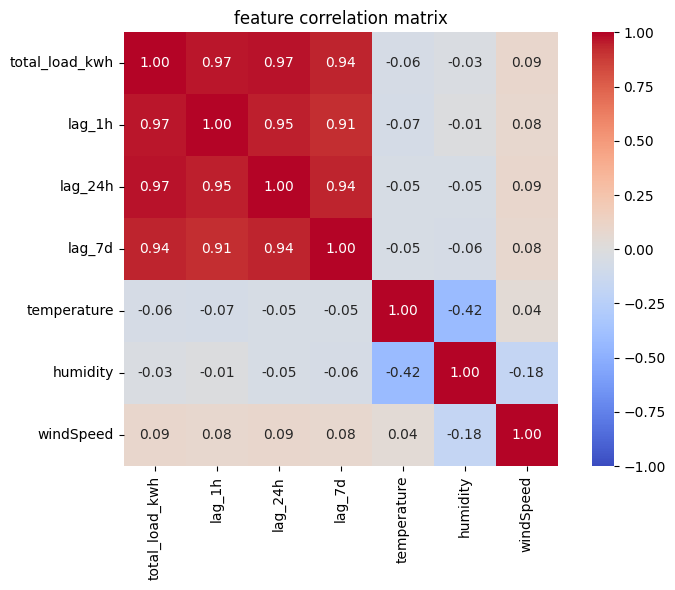

In [15]:
# generate temporary lag columns for correlation inspection
grid_df['lag_1h'] = grid_df['total_load_kwh'].shift(2)
grid_df['lag_24h'] = grid_df['total_load_kwh'].shift(48)
grid_df['lag_7d'] = grid_df['total_load_kwh'].shift(336)

corr_targets = ['total_load_kwh', 'lag_1h', 'lag_24h', 'lag_7d', 'temperature', 'humidity', 'windSpeed']
available_cols = [c for c in corr_targets if c in grid_df.columns]

# plotting
plt.figure(figsize=(8, 6))
sns.heatmap(
    grid_df[available_cols].corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    square=True
)

plt.title("feature correlation matrix")
plt.tight_layout()
plt.savefig('./plots/feature_correlation_matrix.png')
plt.show()